# <u>Market Regime Detection: A Hidden Markov Model Approach</u>

**Author:** Jayden Quang

**Date:** April 22, 2026

**Abstract:** This project uses a multi-state Hidden Markov Model (HMM) on VTI to identify latent market regimes and validates the sensitivity of the Tech (XLK) and Energy (XLE) sectors to those states. The project features exploratory data analysis of daily log returns and volatility clustering, optimization via the Bayesian Information Criterion (BIC), and a correlation heatmap highlighting the relationship between the respective sectors and identified market regimes.

## <u>Environment Setup</u>
Ensures all dependencies and required libraries are installed in the current environment.

In [225]:
import sys
!{sys.executable} -m pip install --upgrade "yfinance>=1.3.0" hmmlearn==0.3.3 scipy pandas numpy matplotlib seaborn

In [226]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*Timestamp.utcnow is deprecated.*"
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from hmmlearn import hmm
import scipy.stats as stats
plt.style.use('seaborn-v0_8')

## Data Ingestion & Preprocessing

Vanguard Total Stock Market ETF (VTI) is used as a dataset for the global state of this project because VTI covers the overall broad US market, capturing over ~4,000 stocks across all sectors. Technology Select Sector SPDR (XLK) and Energy Select Sector SPDR (XLE) serve as the dataset for the tech sector and energy sector respectively as they both cover their own sectors in both breadth and depth, serving as a great benchmark for overall sector behaviors in these periods. The 11-year time period (2015-2026) was chosen to cover full market cycles and to benchmark with commonly known bull/bear regimes (ex: 2020 COVID crash).

In [227]:
def extract_ticker_data():
    # Create yfinance objects with given tickers
    vti_ticker = yf.Ticker("VTI")
    xlk_ticker = yf.Ticker("XLK")
    xle_ticker = yf.Ticker("XLE")

    # Extract OHLCV data from 01/01/2015 -> 01/01/2026 into DataFrame
    vti_df = vti_ticker.history(start="2015-01-01", end="2026-01-01")
    xlk_df = xlk_ticker.history(start="2015-01-01", end="2026-01-01")
    xle_df = xle_ticker.history(start="2015-01-01", end="2026-01-01")
    
    # Combines all ticker DataFrames into a singular DataFrame with daily close prices
    combined_close_df = pd.concat([vti_df['Close'], xlk_df['Close'], xle_df['Close']],
                                  axis=1, keys=['VTI', 'XLK', 'XLE'], join='inner')
    
    return combined_close_df

### Daily Log Returns Formula:
$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right) $$


The daily log return $r_t$ uses today's price $P_t$ and yesterday's price $P_{t-1}$.

This project uses log returns rather than simple returns to show compounding and additivity over time. For example, if a stock goes up 10% one day and down 10% the next, the simple return is 0%, but the actual value of the investment has decreased 1%. Additionally, the sum of daily log returns over a period is equal to the total log return for that entire period, making them much easier to handle when trying to estimate transition probabilities over different time horizons.

In [228]:
def clean_and_calc_log_returns(close_price_df):
    # Check for any NaNs
    if close_price_df.isna().any().any():
        print("Warning: NaNs found in extracted DataFrame")
        close_price_df = close_price_df.dropna()

    # Compute log returns (first row becomes NaN from shift)
    log_returns = np.log(close_price_df / close_price_df.shift(1))

    # Drop the first NaN row
    return log_returns.dropna()

closes = extract_ticker_data()
log_rets = clean_and_calc_log_returns(closes)
print(log_rets.head())

                                VTI       XLK       XLE
Date                                                   
2015-01-05 00:00:00-05:00 -0.017332 -0.015383 -0.042248
2015-01-06 00:00:00-05:00 -0.009847 -0.012130 -0.014799
2015-01-07 00:00:00-05:00  0.011862  0.008432  0.002128
2015-01-08 00:00:00-05:00  0.017486  0.021743  0.022201
2015-01-09 00:00:00-05:00 -0.008325 -0.003147 -0.007957


## Exploratory Data Analysis (EDA)

Taking our cleaned DataFrame of log returns, we can now analyze and plot the daily log returns of each ticker, extracting initial insights to justify our further exploration with Hidden Markov Models. We are looking for three main indicators: non-stationarity, volatility clustering, and excess kurtosis.

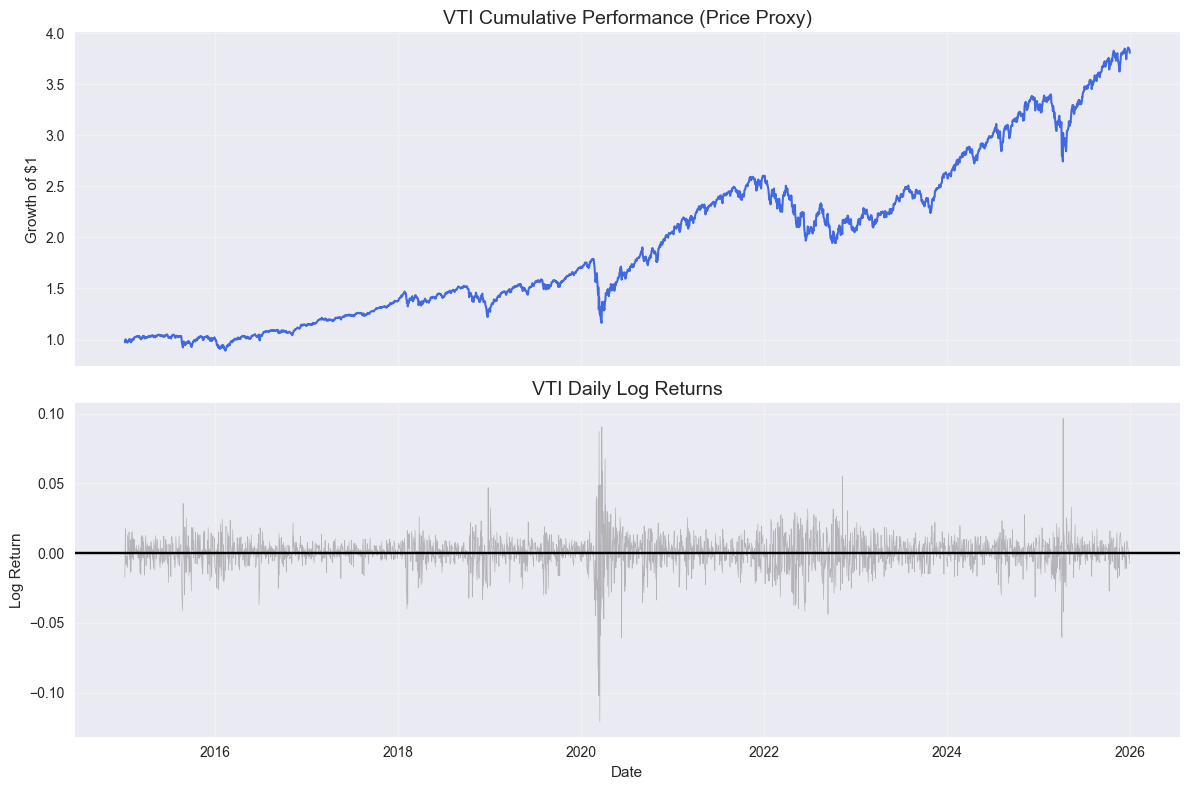

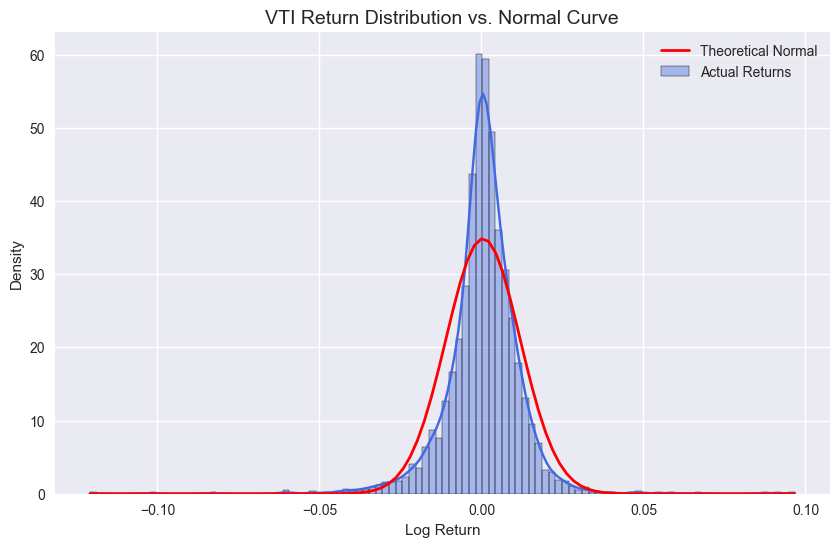

In [229]:
def plot_market_dynamics(log_rets, ticker="VTI"):
    # Initialize overlayed subplot and calculate cumulative returns
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    cumulative_returns = np.exp(log_rets[ticker].cumsum())

    # Create cumulative performance plot
    ax1.plot(cumulative_returns, color="royalblue", lw=1.5)
    ax1.set_title(f"{ticker} Cumulative Performance (Price Proxy)", fontsize=14)
    ax1.set_ylabel("Growth of $1")
    ax1.grid(True, alpha=0.3)

    # Create daily log returns plot
    ax2.plot(log_rets[ticker], color="gray", alpha=0.5, lw=0.5)
    ax2.axhline(0, color="black")
    ax2.set_title(f"{ticker} Daily Log Returns", fontsize=14)
    ax2.set_ylabel("Log Return")
    ax2.set_xlabel("Date")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_distribution(log_rets, ticker='VTI'):
    # Create distribution plot of log returns
    plt.figure(figsize=(10, 6))
    sns.histplot(log_rets[ticker], kde=True, stat="density", color="royalblue", alpha=0.4, label="Actual Returns")
    mu, std = log_rets[ticker].mean(), log_rets[ticker].std()
    x = np.linspace(log_rets[ticker].min(), log_rets[ticker].max(), 100)

    # Overlay normal distribution
    p = stats.norm.pdf(x, mu, std)
    plt.plot(x, p, "r", linewidth=2, label="Theoretical Normal")

    plt.title(f"{ticker} Return Distribution vs. Normal Curve", fontsize=14)
    plt.xlabel("Log Return")
    plt.legend()
    plt.show()
    
plot_market_dynamics(log_rets, "VTI")
plot_distribution(log_rets, "VTI")

The top blue line details the cumulative performance of VTI over time, showing long-term growth. However, it also illustrates that the average price is always moving (non-stationary), making it harder to do math on the moving target. Therefore, by looking at log returns instead, we can force a little stationarity, making it much easier to build models that can actually detect when the market's risk level has shifted.

The gray-colored graph of VTI's daily log returns shows the volatility/movement of the daily log returns. A key takeaway from this plot is the clustering of "spikes" around certain points/periods of time. From this plot, we can see that volatility isn't random; it has a memory. We can start to see how the market flips between "calm" period (thin lines) and "chaotic" periods (thick spikes). This is the visual proof that a single average doesn't work.

The histogram shows that the market is not "normal." The peak of the actual return data is much higher than the suggested normal distribution and is clustered primarily around 0, suggesting that most days are actually very quiet. Additionally, the tails on the far left are a bit fatter or more dense than expected, implying that crashes or rallies may occur more often than standard math predicts.

**<u>What does this mean?</u>** 

These graphs indicate that the market has "mood swings" (regimes). Because volatility is clustered and returns have fat tails, a model that can identify which "mood" the market is in (calm vs. chaotic) will be far more accurate than one that just assumes everything is normal.

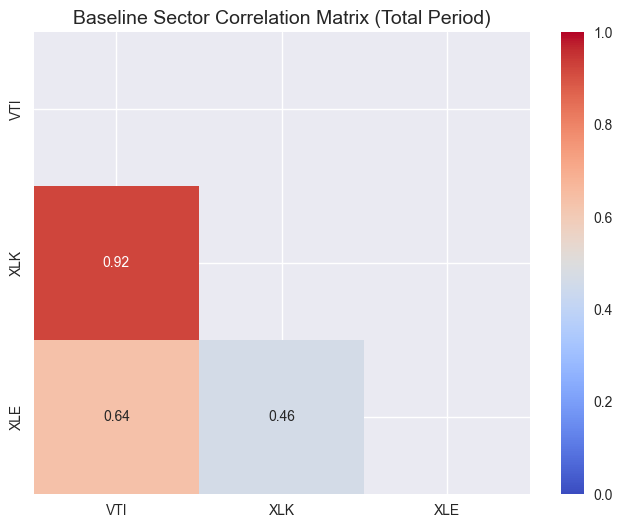

In [230]:
def plot_baseline_correlation(log_rets):
    plt.figure(figsize=(8, 6))
    corr = log_rets.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", mask=mask, vmin=0, vmax=1)
    plt.title("Baseline Sector Correlation Matrix (Total Period)", fontsize=14)
    plt.show()

plot_baseline_correlation(log_rets)

This matrix uses the Pearson Correlation Coefficient to quantify the strength and direction of the linear relationship between the daily log returns of each ticker. On average, Technology and Energy show a **0.92** and **0.64** correlation respectively. However, these general numbers only highlight each ticker's average performance in the long-run, masking how these sectors interact during different market moods. This heatmap serves as our baseline to compare against our regime-specific heatmaps later in the analysis.

## Model Selection & Parameter Tuning

To avoid overfitting our model, we use the Bayesian Information Criterion (BIC) to mathematically determine the optimal number of hidden states. If we simply evaluate models based on accuracy, a model with 6 states will always "outperform" a model with 2 states because it has more parameters to memorize the data.

To solve this, we use the **Bayesian Information Criterion (BIC)**, which calculates the Goodness of Fit but introduces a strict penalty for adding parameters/complexity.

The BIC is calculated as:
$$BIC = k \ln(n) - 2\ln(\hat{L})$$

Where:
- $k$ = The number of parameters estimated by the model.
- $n$ = The number of observations (days of market data).
- $\hat{L}$ = The maximized log-likelihood of the model.

The HMM will attempt to fit the data using different state configurations (n=2 through n=6). The optimal model is the one that achieves the **lowest BIC score**, representing the perfect balance between accuracy and simplicity.

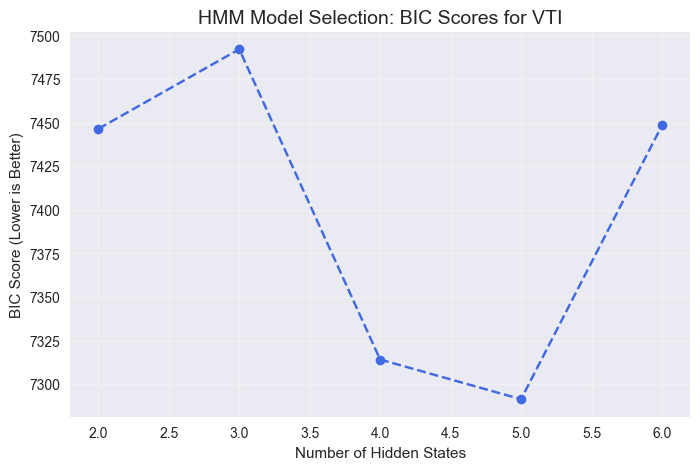

In [231]:
def plot_bic_scores(df, ticker="VTI", max_states=6):
    X = df[[ticker]].dropna().values * 100

    states_range = range(2, max_states + 1)
    bic_scores = []

    for n in states_range:
        model = hmm.GaussianHMM(n_components=n, covariance_type="full", n_iter=1000, tol=0.01, random_state=42)
        model.fit(X)
        bic_scores.append(model.bic(X))
    
    plt.figure(figsize=(8, 5))
    plt.plot(states_range, bic_scores, marker="o", linestyle="--", color="royalblue")
    plt.title(f"HMM Model Selection: BIC Scores for {ticker}", fontsize=14)
    plt.xlabel("Number of Hidden States")
    plt.ylabel("BIC Score (Lower is Better)")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_bic_scores(log_rets, "VTI")

Based on the plot, there is a steep, consistent drop in the BIC score as we move from n = 2 to n = 4 states. This indicates that simpler models (like the standard Bull/Bear binary) are **underfitting** the data. At n = 5, the plot reaches its **global minimum**, achieving the maximum explanatory power (likelihood) before the penalty (complexity) begins to outweight the benefits. At n = 6, the BIC score begins to rise again, suggesting that a 6-state model would likely begin **overfitting**, memorizing random noise and outliers in the market data.

## Final Model Fitting & Global Regime Decoding

Based on the BIC results, we will now fit a 5-state Gaussian HMM to the VTI log returns. We will extract the characteristics or "signature" of each state, defined by its mean return and variance, to translate these abstract mathematical labels into recognizable market conditions. Because the HMM assigns state labels randomly during training, we will programmatically sort the states by their mean return, ensuring that "State 0" always represents the worst market regime and "State 4" represents the strongest bull regime.

In [232]:
def fit_and_extract_signatures(log_rets, ticker="VTI", n_states=5):
    X = log_rets[[ticker]].dropna().values * 100

    model = hmm.GaussianHMM(n_components=n_states, covariance_type="full", n_iter=1000,  tol=0.01, random_state=42)
    model.fit(X)
    hidden_states = model.predict(X)

    # Extract means and volatility
    means = model.means_.flatten()
    vols = np.sqrt(np.array([model.covars_[i][0][0] for i in range(n_states)]))

    # Sort states by mean return (worst -> best)
    sorted_idx = np.argsort(means)
    state_map = {old: new for new, old in enumerate(sorted_idx)}

    # Map predictions to new sorted state numbers
    sorted_states = np.array([state_map[s] for s in hidden_states])

    # Create clean summary df
    summary_data = []
    for new_state in range(n_states):
        old_state = sorted_idx[new_state]
        summary_data.append({
            "State": new_state,
            "Mean Return (%)": means[old_state],
            "Volatility (%)": vols[old_state]
        })
    
    df_summary = pd.DataFrame(summary_data).set_index("State")
    print(f"--- {ticker} 5-State Regime Signatures ---")
    display(df_summary)

    return sorted_states, df_summary

log_rets["VTI_State"], state_summary = fit_and_extract_signatures(log_rets, "VTI", 5)

--- VTI 5-State Regime Signatures ---


,Mean Return (%),Volatility (%)
State,,
0,-0.623265,4.895283
1,-0.110545,0.282572
2,-0.059434,1.464695
3,0.081926,0.809463
4,0.328202,0.375687


Here, we uncover our "hidden" states and see the fundamental characteristics that make up each one. 
- State 0 (Severe Bear / Crisis): Most extreme regime, massive negative mean returns and extreme volatility
- State 1 (Low-Volatility Drift): A curious state, slightly negative returns, very low volatility
- State 2 (Volatile Sideways): Negative mean returns, high volatility, uncertainty is high and direction is unclear
- State 3 (Steady Growth): Standard "bull" environment, consistent positive returns, moderate volatility
- State 4 (High-Conviction Bull): "Goldilocks" state, high daily returns, very low volatility

## Visualizing the Hidden Market

To validate the model's "economic reality," we overlay the discovered regimes onto the VTI price chart. This allows us to see if the model successfully identified historical events like the COVID-19 crash or the 2022 inflationary bear market without being explicitly told they occurred. Since we sorted our states, we can apply a consistent color gradient: Dark Red represents State 0 (Severe Bear) up through Dark Green for State 4 (Strong Bull).

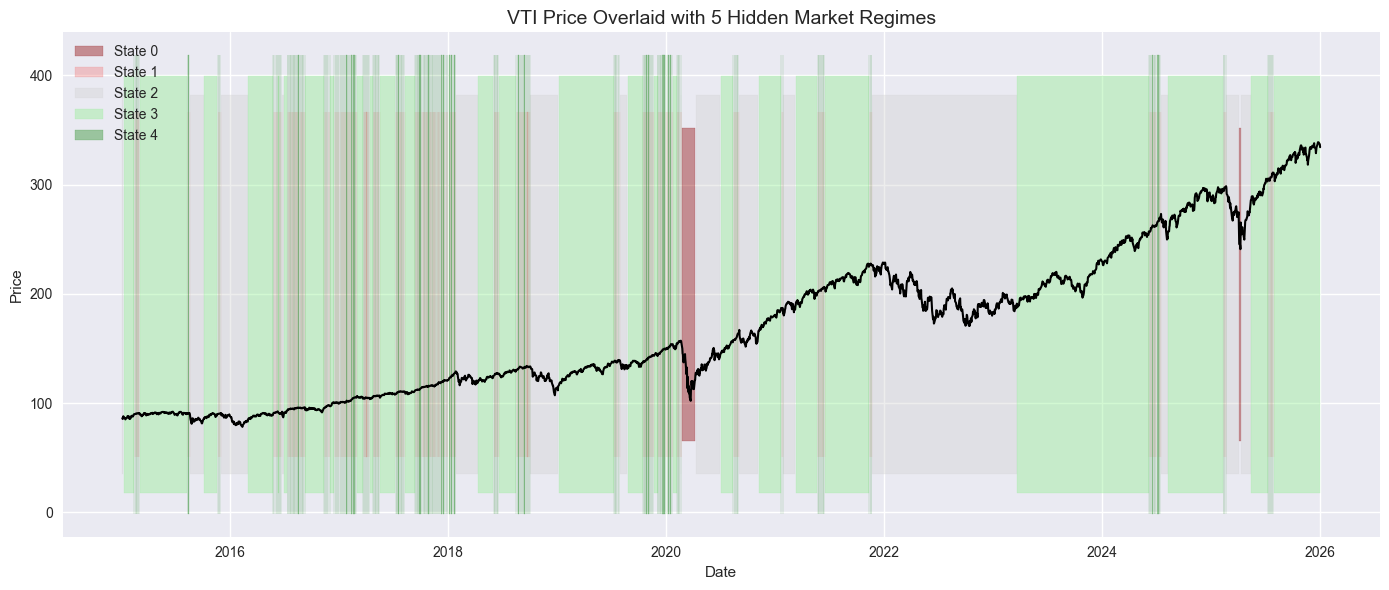

In [233]:
def plot_hidden_regimes(log_rets, prices, ticker="VTI", n_states=5):
    fig, ax = plt.subplots(figsize=(14, 6))
    dates = log_rets.index
    aligned_prices = prices.loc[dates, ticker]

    ax.plot(dates, aligned_prices, color="black", lw=1.5)

    # Color gradient
    colors = ["darkred", "lightcoral", "lightgray", "lightgreen", "forestgreen"]

    for i in range(n_states):
        ax.fill_between(dates, ax.get_ylim()[0], ax.get_ylim()[1],
                        where=(log_rets["VTI_State"] == i),
                        color=colors[i], alpha=0.4, label=f"State {i}")
    
    ax.set_title(f"{ticker} Price Overlaid with 5 Hidden Market Regimes", fontsize=14)
    ax.set_ylabel("Price")
    ax.set_xlabel("Date")

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper left")

    plt.tight_layout()
    plt.show()

plot_hidden_regimes(log_rets, closes, "VTI", 5)

Inspection of the price overlay confirms the presence of **regime inertia**. The model does not flicker randomly; instead, it identifies the sustained "clumps" of color. This proves the HMM is detecting significant structural shifts in market dynamics rather than reacting to daily noise. For example, the State 0 (Severe Bear) blocks align with major historical shocks like the March 2020 (aka COVID-19) crash. This clustering validates that market states have a kind of memory, once the market enters a state of panic or growth, it tends to stay there.

## Sector Sensitivity & Correlation Convergence

This is the core of our validation. We check if the "Global States" defined by the Total Market (VTI) actually change the behavior of Technology (XLK) and Energy (XLE). We specifically look for "Correlation Convergence," the tendency for all sectors to correlate to 1.0 during high-volatility regimes.

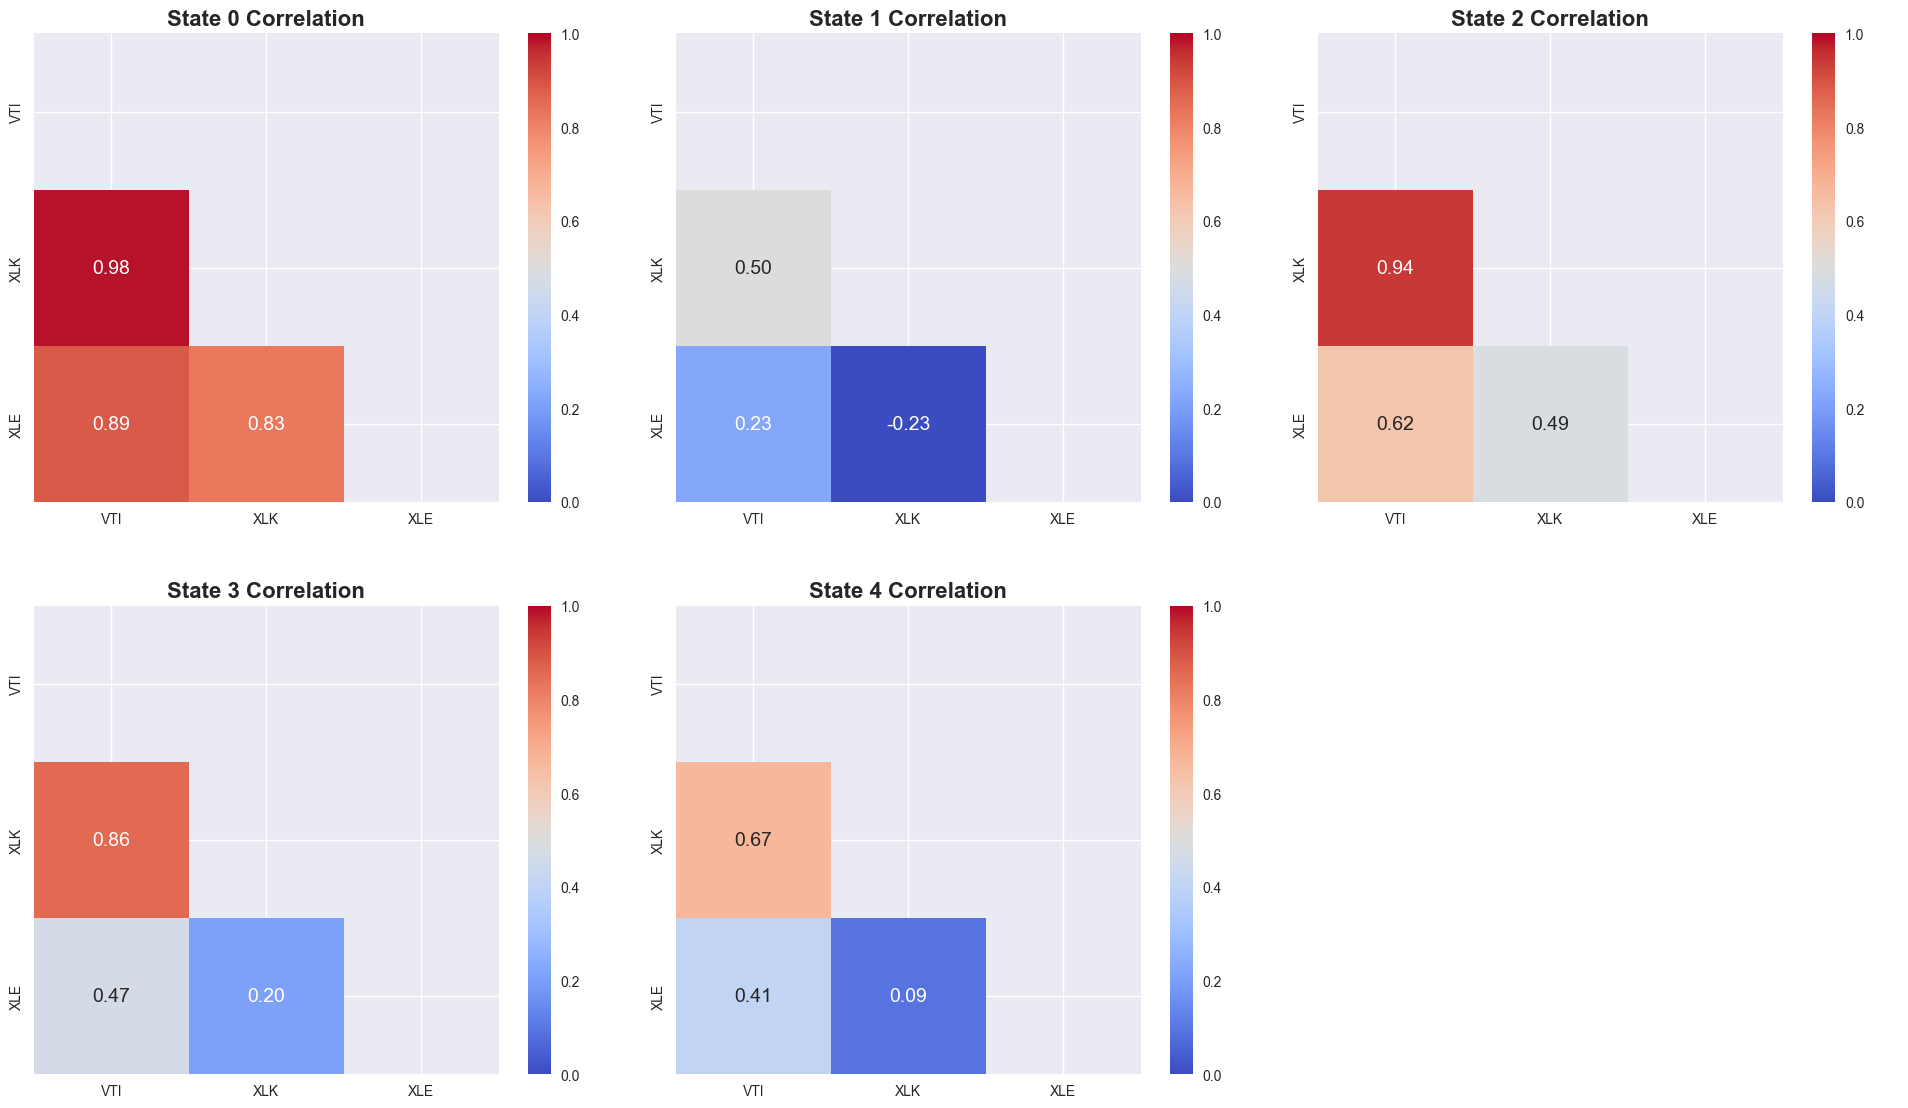

In [234]:
def plot_5_state_correlations(log_rets):
    # Create 3x2 grid for heatmaps
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    for i in range(5):
        state_data = log_rets[log_rets["VTI_State"] == i][["VTI", "XLK", "XLE"]]

        if not state_data.empty:
            corr = state_data.corr()
            mask = np.triu(np.ones_like(corr, dtype=bool))
            sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", mask=mask,
                        vmin=0, vmax=1, ax=axes[i], cbar=True,
                        annot_kws={"size": 14})
        axes[i].set_title(f"State {i} Correlation", fontsize=16, fontweight="bold")
    
    axes[5].axis("off")
    
    plt.tight_layout(pad=4.0)
    plt.show()
    
plot_5_state_correlations(log_rets)

The regime-conditional heatmaps provide the most significant finding of this project: **Market State dictates Sector Autonomy**. We observe a dramatic shift in how Tech (XLK) and Energy (XLE) relate to the broad markets (VTI) as conditions transition from Bull to Bear.
- Severe Bear / Crisis (State 0): 
  - Correlation between **XLK and VTI is nearly perfect at 0.96**, while **XLE and VTI follow closely at 0.89**
  - VTI becomes the single point of failure; individual sectors have no room to move independently
  -  The high cross-sector correlation of **0.83** between Tech and Energy confirms that in a crisis, diversification is an illusion
- High-Conviction Bull (State 4):
  - Correlation of **XLK to VTI drop to 0.67**, and **XLE to VTI falls to 0.41**.
  - Sectors exhibit **Idiosyncratic Behavior** (unique behavior)
  - Negligible **0.09 correlation** between XLE and XLK, means diversification is possible

## Conclusion & Model Critique

**Objective Met:** By utilizing a 5-state Gaussian HMM and optimizing via BIC, we successfully moved beyond a simple "Bull/Bear" system. The model identified that the market exists in distinct micro-regimes, including a "low-volatility drift" (State 1) and a "volatile sideways" (State 2) phase that a simpler model would have missed.

**Key Insight:** The study confirms that **Market State dictates Sector Relationship**. The jump in XLK-XLE correlation from 0.09 in a rally to 0.83 in a crash proves that diversification is regime-dependent.

**Practical Application:** A quant trader could use this model as a risk signal. If the model detects a transition from State 4 into State 2 or 0, it suggests that diversification will no longer protect a portfolio, and a reduction in total exposure is necessary.

**Critical Weakness:** The model is fundamentally **lagging**. Because the HMM relies on the Markov property, it requires a spike in volatility to occur before it can reclassify the state. While it is an excellent tool for diagnostic analysis and risk management, its predictive power for the first day or initial turn of a crash is limited.